# 📊 Telecom X – Parte 2: Predicción de Cancelación (Churn)

**👨‍💻Autor**

**Daniel Gallardo**

*Analista Junior de Machine Learning*

## Introducción

📣 Contexto del Proyecto

Después de realizar un análisis exploratorio sobre la cancelación de clientes en Telecom X, el siguiente paso estratégico es desarrollar modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios.

La cancelación (Churn) representa un impacto directo en los ingresos de la compañía, por lo que contar con un modelo predictivo permitirá implementar acciones preventivas y mejorar la retención de clientes.

## Objetivo del Proyecto

🎯 Objetivo General

Desarrollar y evaluar modelos de clasificación capaces de predecir la probabilidad de cancelación de clientes.

🎯 Objetivos Específicos

- Preparar los datos para el modelado (limpieza, codificación y normalización).

- Analizar correlaciones y seleccionar variables relevantes.

- Entrenar al menos dos modelos de clasificación.

- Evaluar el desempeño mediante métricas.

- Interpretar la importancia de las variables.

- Generar conclusiones estratégicas basadas en los resultados.

## Desarrollo

### Importación de Librerias

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


### Carga y Limpieza de Columnas

In [1]:
# Link desde el repositirio de GitHub
url = 'https://raw.githubusercontent.com/DaniGa-Mo/Challenge_TelecomX_2/refs/heads/main/datos_tratados.csv'

In [3]:
# Lectura del archivo
df = pd.read_csv(url)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


En esta etapa, eliminamos las columnas que no aportan información útil para que el modelo identifique patrones de cancelación (Churn).

In [4]:
# Definimos la lista de columnas a eliminar
columnas_a_eliminar = ['customerID', 'Cuentas_Diarias']

# Eliminamos las columnas del DataFrame
# axis=1 indica que son columnas, inplace=True aplica los cambios al DF original
df.drop(columns=columnas_a_eliminar, axis=1, inplace=True)

# Verificamos que las columnas hayan sido eliminadas
print(f"Columnas restantes: {df.columns.tolist()}")
df.head()

Columnas restantes: ['Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40


### Codificación de Variables Categóricas (Encoding)

Transformamos las columnas de texto en representaciones numéricas. Utilizaremos get_dummies de pandas con el parámetro drop_first=True para evitar la redundancia matemática (trampa de la variable ficticia).

In [6]:
# Identificamos las columnas que son de tipo 'object' (texto)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas a codificar: {columnas_categoricas}")

Columnas a codificar: ['customer.gender', 'internet.InternetService', 'account.Contract', 'account.PaymentMethod']


In [7]:
# Aplicamos One-Hot Encoding
# drop_first=True elimina la primera categoría de cada variable para evitar multicolinealidad
df_final = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# Convertir booleanos resultantes (True/False) a enteros (1/0)
df_final = df_final.astype(int, errors='ignore')

# Visualizamos el resultado
print(f"Nuevo total de columnas: {len(df_final.columns)}")
df_final.head()

Nuevo total de columnas: 24


,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,...,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,65,593,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,59,542,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,73,280,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,98,1237,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,83,267,0,1,0,0,0,0,0,1


In [9]:
# 1. Definimos las columnas numéricas que necesitan escala (no las binarias/dummies)
columnas_numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento solo a esas columnas
# Es importante mantener el DataFrame final con las variables ya codificadas
df_final[columnas_numericas] = scaler.fit_transform(df_final[columnas_numericas])

# Verificamos que ahora los valores estén en una escala similar (cerca de 0)
print("Primeras filas con datos escalados:")
df_final[columnas_numericas].head()

Primeras filas con datos escalados:


,customer.tenure,account.Charges.Monthly,account.Charges.Total
0,-0.951682,0.023399,-0.743953
1,-0.951682,-0.175998,-0.766453
2,-1.155283,0.289263,-0.882043
3,-0.788800,1.120088,-0.459830
4,-1.196004,0.621593,-0.887778


### Análisis del Balance de Clases

Antes de modelar, debemos entender la distribución de nuestra variable objetivo (Churn). El desbalance de clases ocurre cuando una de las categorías es significativamente más frecuente que la otra.

¿Por qué es un problema?

- Sesgo del Modelo: Si el 90% de los clientes no cancelan, un modelo "perezoso" podría simplemente predecir siempre "No cancela" y tener un 90% de precisión (Accuracy), fallando totalmente en detectar a los clientes que realmente se van a ir.

- Métricas de Evaluación: En datos desbalanceados, el Accuracy es una métrica engañosa. Debemos prestar más atención al Recall (sensibilidad) y al F1-Score para asegurar que estamos capturando los casos de Churn reales.

In [15]:
# 1. Obtener el conteo absoluto de cada clase
conteo_churn = df_final['Churn'].value_counts()

# 2. Obtener la proporción porcentual
proporcion_churn = df_final['Churn'].value_counts(normalize=True) * 100

# 3. Mostrar resultados de forma legible
print("--- Distribución de la variable Churn ---")
print(f"Cantidades absolutas:\n{conteo_churn}")
print(f"\nProporciones porcentuales:\n{proporcion_churn.map('{:.2f}%'.format)}")

--- Distribución de la variable Churn ---
Cantidades absolutas:
Churn
0    5174
1    1869
Name: count, dtype: int64

Proporciones porcentuales:
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: object


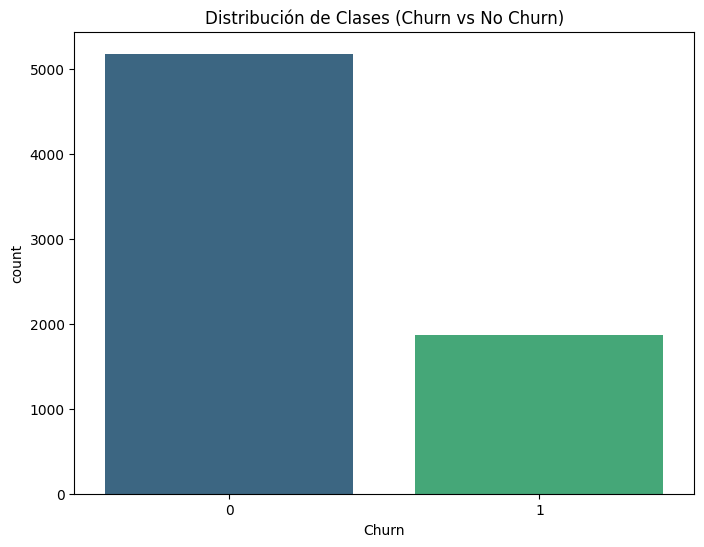

In [24]:
# Visualización rápida para el notebook
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=df_final, palette='viridis', hue='Churn', legend=False)
plt.title('Distribución de Clases (Churn vs No Churn)')
plt.show()

### Balanceo de Datos (SMOTE)

El Oversampling mediante SMOTE (Synthetic Minority Over-sampling Technique) no simplemente duplica filas existentes (lo cual causaría overfitting), sino que crea nuevos ejemplos sintéticos basados en la distancia matemática entre los puntos de la clase minoritaria.

¿Por qué elegir SMOTE frente a Undersampling?

- No perdemos información: El Undersampling elimina filas de la clase mayoritaria, lo cual es un desperdicio de datos valiosos.

- Mejora la Generalización: Al crear datos sintéticos "intermedios", ayudamos al modelo a definir mejor la frontera de decisión entre un cliente que se queda y uno que se va.

In [26]:
# 1. Separamos las características (X) de la variable objetivo (y)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Primero dividimos en entrenamiento y prueba (IMPORTANTE)
# El balanceo solo debe hacerse sobre los datos de ENTRENAMIENTO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Inicializamos SMOTE
smote = SMOTE(random_state=42)

# 4. Aplicamos el balanceo solo a los datos de entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 5. Verificamos el nuevo balanceo
print("Distribución antes de SMOTE (Entrenamiento):", y_train.value_counts().to_dict())
print("Distribución después de SMOTE (Entrenamiento):", y_train_res.value_counts().to_dict())

Distribución antes de SMOTE (Entrenamiento): {0: 4139, 1: 1495}
Distribución después de SMOTE (Entrenamiento): {0: 4139, 1: 4139}


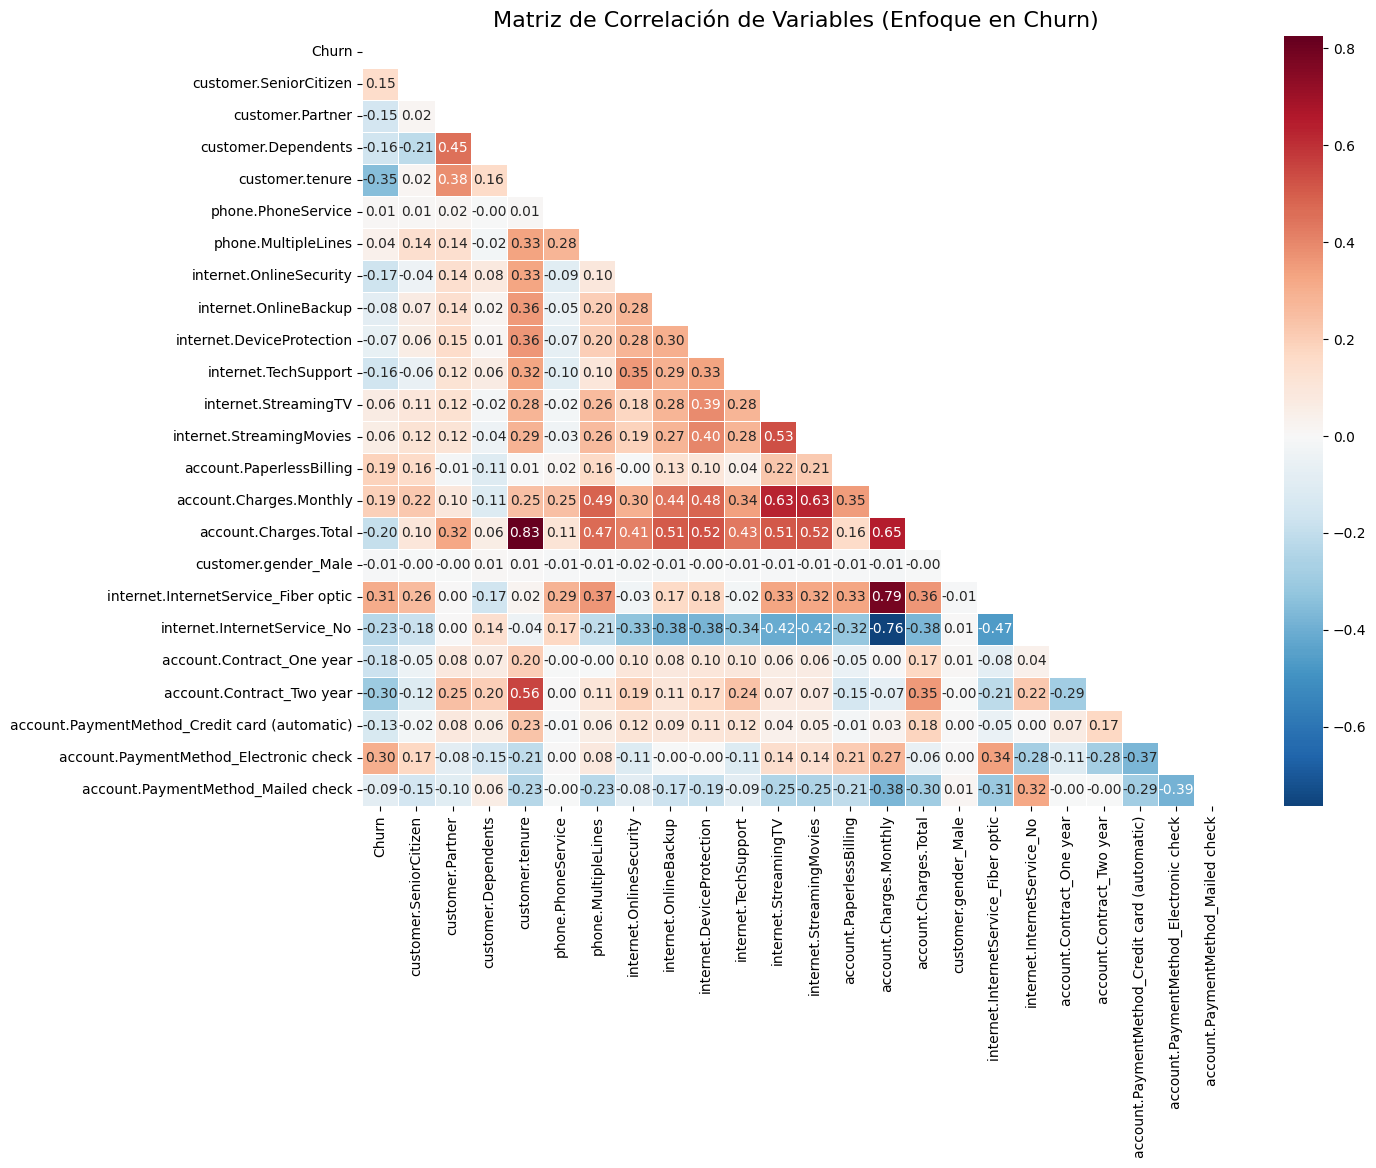

--- Correlación de las variables con respecto a Churn ---
Churn                                            1.000000
internet.InternetService_Fiber optic             0.308020
account.PaymentMethod_Electronic check           0.301919
account.Charges.Monthly                          0.193422
account.PaperlessBilling                         0.191825
customer.SeniorCitizen                           0.150889
internet.StreamingTV                             0.063228
internet.StreamingMovies                         0.061382
phone.MultipleLines                              0.040102
phone.PhoneService                               0.011942
customer.gender_Male                            -0.008612
internet.DeviceProtection                       -0.066160
internet.OnlineBackup                           -0.082255
account.PaymentMethod_Mailed check              -0.091683
account.PaymentMethod_Credit card (automatic)   -0.134302
customer.Partner                                -0.150448
customer.Depen

In [27]:
# 1. Calculamos la matriz de correlación
corr_matrix = df_final.corr()

# 2. Configuramos el tamaño de la figura
plt.figure(figsize=(14, 10))

# 3. Creamos una máscara para mostrar solo la mitad inferior (opcional, para limpieza visual)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Muestra los números en los cuadros
            fmt=".2f",           # Limita a 2 decimales
            cmap='RdBu_r',       # Escala de colores: Rojo (negativo) a Azul (positivo)
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación de Variables (Enfoque en Churn)', fontsize=16)
plt.show()

# 5. Extraer específicamente las correlaciones con Churn ordenadas
print("--- Correlación de las variables con respecto a Churn ---")
print(corr_matrix['Churn'].sort_values(ascending=False))